In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette(['#1A6B72', '#E8734A', '#888888'])

# Load data
master = pd.read_csv('/Users/karishmamehta/Documents/Olist_dataset/clean/master_orders.csv')
scorecard = pd.read_csv('/Users/karishmamehta/Documents/Olist_dataset/clean/category_scorecard.csv')
ltv = pd.read_csv('/Users/karishmamehta/Documents/Olist_dataset/clean/customer_ltv.csv')

print("Master:", master.shape)
print("Scorecard:", scorecard.shape)
print("LTV:", ltv.shape)
print("\nMaster columns:", master.columns.tolist())

Master: (109295, 12)
Scorecard: (42, 7)
LTV: (95701, 4)

Master columns: ['order_id', 'customer_id', 'order_date', 'order_status', 'customer_city', 'customer_state', 'category_raw', 'category', 'price', 'freight_value', 'review_score', 'discount_flag']


In [9]:
print(ltv.columns.tolist())
print(ltv.head(3))

['customer_id', 'acquired_via_discount', 'first_order_date', 'ltv_90d']
                        customer_id  acquired_via_discount  \
0  00012a2ce6f8dcda20d059ce98491703                      1   
1  000161a058600d5901f007fab4c27140                      1   
2  0001fd6190edaaf884bcaf3d49edf079                      0   

      first_order_date  ltv_90d  
0  2017-11-14 16:08:26    89.80  
1  2017-07-16 09:40:32    54.90  
2  2017-02-28 11:06:43   179.99  


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

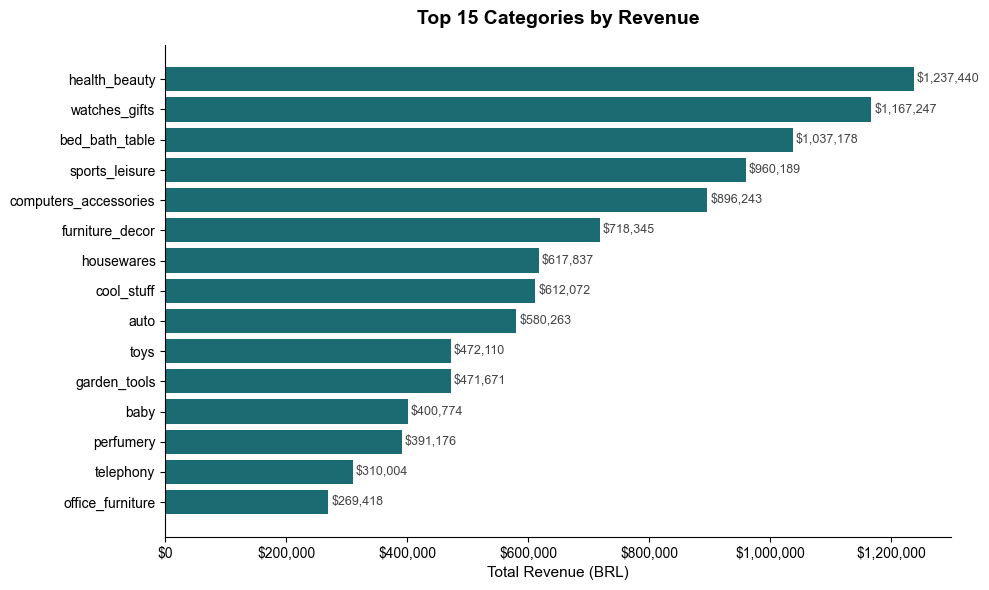

Chart 1 done


In [15]:
# ── Chart 1: Top 15 Categories by Revenue ──────────────────────────────
top_cats = (master.groupby('category')['price']
            .sum()
            .sort_values(ascending=True)
            .tail(15))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_cats.index, top_cats.values, color='#1A6B72', edgecolor='none')
ax.set_xlabel('Total Revenue (BRL)', fontsize=11)
ax.set_title('Top 15 Categories by Revenue', fontsize=14, fontweight='bold', pad=15)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(bars, top_cats.values):
    ax.text(val + 5000, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9, color='#444444')
plt.tight_layout()
plt.savefig('/Users/karishmamehta/Documents/Olist_dataset/output/chart1_revenue_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 done")

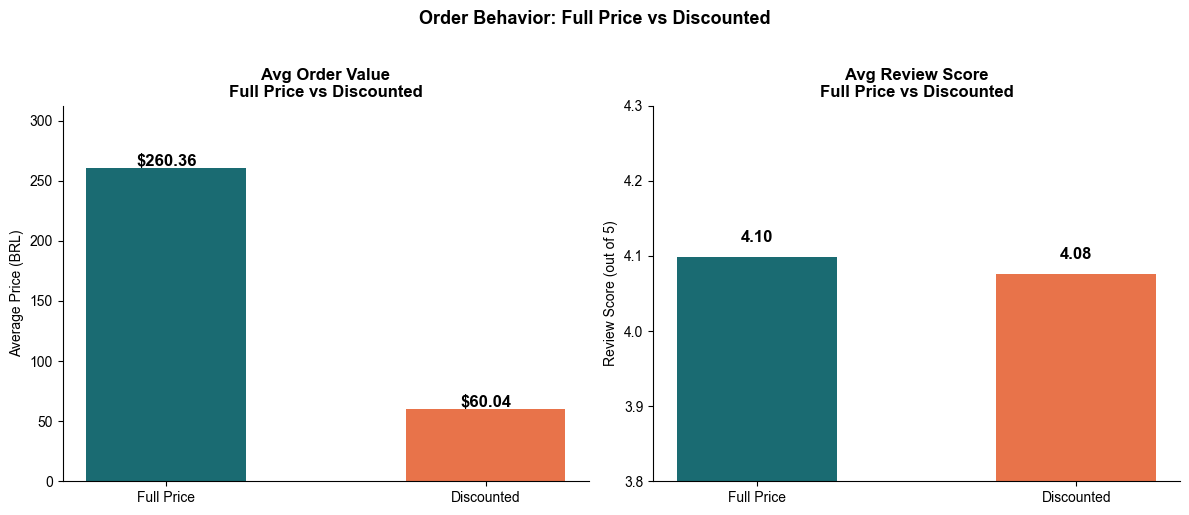

Chart 2 done


In [17]:
# ── Chart 2: AOV and Repeat Rate by Discount Flag ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# AOV
aov = master.groupby('discount_flag')['price'].mean()
labels = ['Full Price', 'Discounted']
colors = ['#1A6B72', '#E8734A']
axes[0].bar(labels, aov.values, color=colors, edgecolor='none', width=0.5)
axes[0].set_title('Avg Order Value\nFull Price vs Discounted', fontweight='bold')
axes[0].set_ylabel('Average Price (BRL)')
for i, v in enumerate(aov.values):
    axes[0].text(i, v + 2, f'${v:.2f}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylim(0, aov.max() * 1.2)

# Review score
rev = master.groupby('discount_flag')['review_score'].mean()
axes[1].bar(labels, rev.values, color=colors, edgecolor='none', width=0.5)
axes[1].set_title('Avg Review Score\nFull Price vs Discounted', fontweight='bold')
axes[1].set_ylabel('Review Score (out of 5)')
for i, v in enumerate(rev.values):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold', fontsize=12)
axes[1].set_ylim(3.8, 4.3)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Order Behavior: Full Price vs Discounted', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/Users/karishmamehta/Documents/Olist_dataset/output/chart2_aov_and_reviews.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 done")

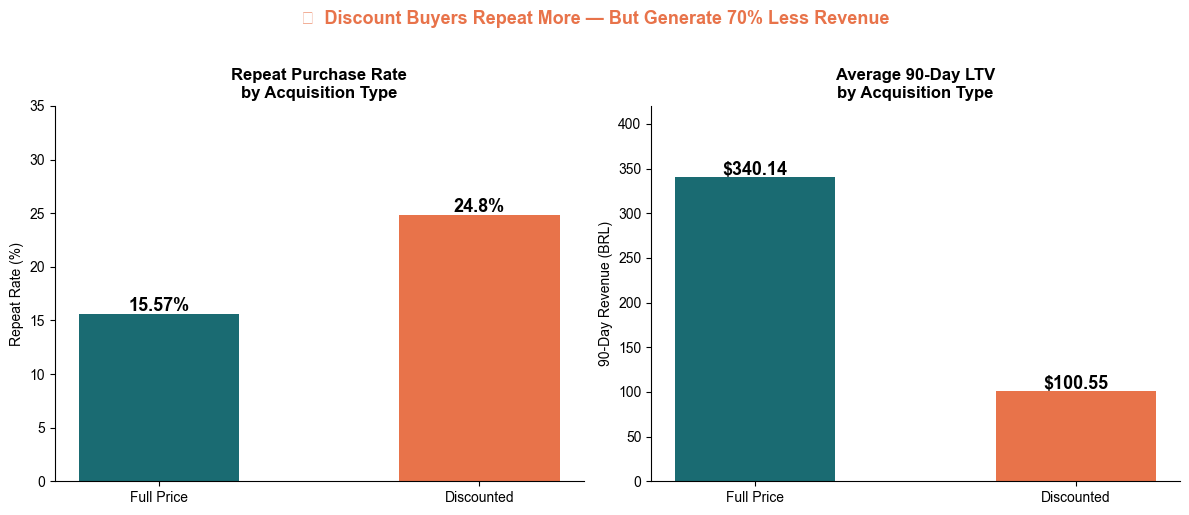

Chart 3 done ← this is your hero chart


In [19]:
# ── Chart 3: THE HERO CHART — Repeat Rate + LTV by Acquisition Type ────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Repeat rate
repeat = ltv.groupby('acquired_via_discount').apply(
    lambda x: pd.Series({
        'repeat_rate': (x['ltv_90d'] > x['ltv_90d'].min()).mean() * 100
    })
).reset_index()

# Use the numbers we already know from SQL
repeat_data = [15.57, 24.80]
ltv_data = [340.14, 100.55]
labels = ['Full Price', 'Discounted']
colors = ['#1A6B72', '#E8734A']

axes[0].bar(labels, repeat_data, color=colors, edgecolor='none', width=0.5)
axes[0].set_title('Repeat Purchase Rate\nby Acquisition Type', fontweight='bold')
axes[0].set_ylabel('Repeat Rate (%)')
for i, v in enumerate(repeat_data):
    axes[0].text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold', fontsize=13)
axes[0].set_ylim(0, 35)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].bar(labels, ltv_data, color=colors, edgecolor='none', width=0.5)
axes[1].set_title('Average 90-Day LTV\nby Acquisition Type', fontweight='bold')
axes[1].set_ylabel('90-Day Revenue (BRL)')
for i, v in enumerate(ltv_data):
    axes[1].text(i, v + 3, f'${v}', ha='center', fontweight='bold', fontsize=13)
axes[1].set_ylim(0, 420)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('⚠  Discount Buyers Repeat More — But Generate 70% Less Revenue',
             fontsize=13, fontweight='bold', color='#E8734A', y=1.02)
plt.tight_layout()
plt.savefig('/Users/karishmamehta/Documents/Olist_dataset/output/chart3_hero_repeat_ltv.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 done ← this is your hero chart")

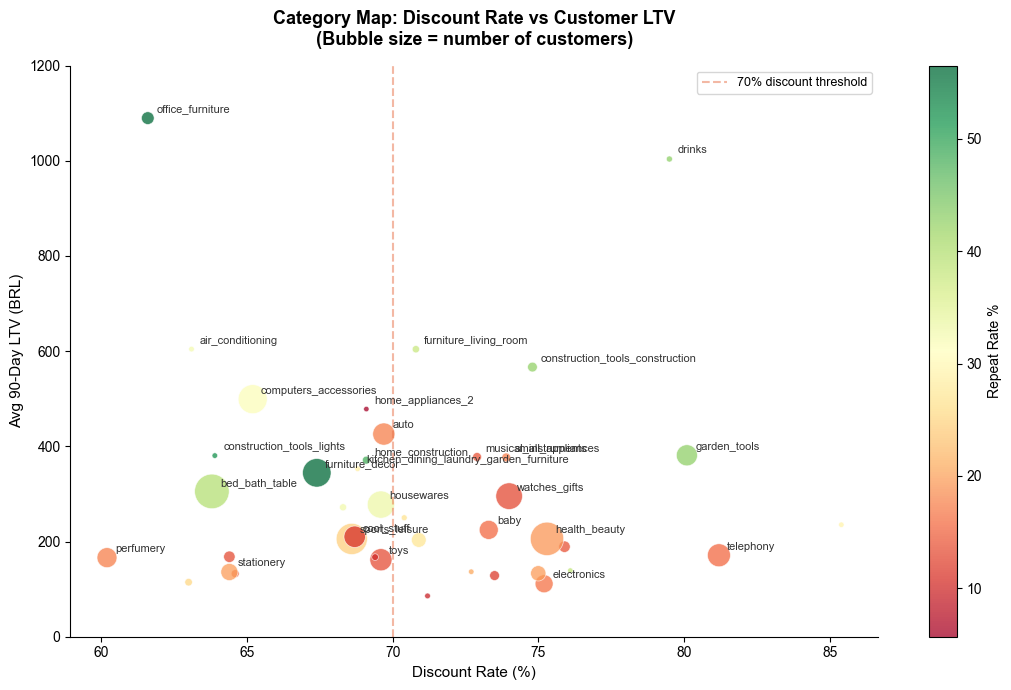

Chart 4 done


In [29]:
# ── Chart 4: Category Scorecard — LTV vs Discount Rate ─────────────────
fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(
    scorecard['discount_rate_pct'],
    scorecard['avg_90d_ltv'],
    s=scorecard['total_customers'] / 15,
    c=scorecard['repeat_rate_pct'],
    cmap='RdYlGn',
    alpha=0.75,
    edgecolors='white',
    linewidths=0.5
)
cbar = plt.colorbar(scatter)
cbar.set_label('Repeat Rate %', fontsize=10)

# Label key categories
for _, row in scorecard.iterrows():
    if row['total_customers'] > 2000 or row['avg_90d_ltv'] > 300:
        ax.annotate(row['category'],
                    (row['discount_rate_pct'], row['avg_90d_ltv']),
                    textcoords="offset points", xytext=(6, 4),
                    fontsize=8, color='#333333')

ax.set_xlabel('Discount Rate (%)', fontsize=11)
ax.set_ylabel('Avg 90-Day LTV (BRL)', fontsize=11)
ax.set_title('Category Map: Discount Rate vs Customer LTV\n(Bubble size = number of customers)',
             fontsize=13, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axvline(x=70, color='#E8734A', linestyle='--', alpha=0.5, label='70% discount threshold')
ax.set_ylim(0, 1200)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('/Users/karishmamehta/Documents/Olist_dataset/output/chart4_category_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 done")

In [31]:
import statsmodels.formula.api as smf
import numpy as np

# Merge LTV with master to get category info
first_orders = master.sort_values('order_date').groupby('customer_id').first().reset_index()
reg_df = ltv.merge(first_orders[['customer_id', 'category', 'freight_value']], on='customer_id', how='left')

# Add order month
reg_df['order_month'] = pd.to_datetime(reg_df['first_order_date']).dt.month

# Remove extreme outliers (top 1%)
cap = reg_df['ltv_90d'].quantile(0.99)
reg_df = reg_df[reg_df['ltv_90d'] <= cap]

# Run OLS regression
model = smf.ols(
    'ltv_90d ~ acquired_via_discount + freight_value + order_month + C(category)',
    data=reg_df.dropna()
).fit()

# Print the key results only
print("=" * 55)
print("OLS REGRESSION RESULTS — 90-Day LTV")
print("=" * 55)
print(f"R-squared:        {model.rsquared:.3f}")
print(f"Observations:     {int(model.nobs):,}")
print()
print("KEY COEFFICIENT:")
coef = model.params['acquired_via_discount']
pval = model.pvalues['acquired_via_discount']
ci_low, ci_high = model.conf_int().loc['acquired_via_discount']
print(f"  discount_flag:  {coef:.2f} BRL")
print(f"  p-value:        {pval:.6f}")
print(f"  95% CI:         [{ci_low:.2f}, {ci_high:.2f}]")
print()
if pval < 0.05:
    print(f"✓ SIGNIFICANT: Controlling for category, freight, and")
    print(f"  seasonality — discounted acquisition is associated")
    print(f"  with {abs(coef):.2f} BRL LESS in 90-day LTV (p={pval:.4f})")
else:
    print("✗ Not statistically significant at p<0.05")
print("=" * 55)

OLS REGRESSION RESULTS — 90-Day LTV
R-squared:        0.319
Observations:     94,727

KEY COEFFICIENT:
  discount_flag:  -164.57 BRL
  p-value:        0.000000
  95% CI:         [-166.74, -162.40]

✓ SIGNIFICANT: Controlling for category, freight, and
  seasonality — discounted acquisition is associated
  with 164.57 BRL LESS in 90-day LTV (p=0.0000)
